# K-Nearest Neighbors para EMNIST Digits

En esta práctica se utiliza el algoritmo de KNN para la clasificación de los dígitos del dataset **EMNIST Digits**. Se clasifican las imágenes de los dígitos del 0 al 9.

El flujo del notebook es:
1. Cargar los datos
2. Utilizar los datos de entrenamiento para ver las métricas
3. Ver las métricas de los datos

## Instalación de librerías

Se utilizan librerías para cargar los datos y para las métricas.

In [6]:
from src.knn import predecir_masa_knn_fast
from src.distancias import obtener_distancia
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

DISTANCIA = "euclidea"
f_distancia = obtener_distancia(DISTANCIA)


## Carga de datos

Se cargan los datos desde `tensorflow_datasets`. Se dividen entre datos de entrenamiento y de testeto, para verificar la correctitud del modelo y para la obtención de métricas posteriormente.

In [7]:
(ds_train, ds_test), ds_info = tfds.load(
        "emnist/digits", 
        split=["train", "test"], 
        as_supervised=True, 
        with_info=True
    )

train_size = ds_info.splits["train"].num_examples
test_size = ds_info.splits["test"].num_examples

x_train, y_train = next(iter(tfds.as_numpy(ds_train.batch(train_size))))
x_test, y_test = next(iter(tfds.as_numpy(ds_test.batch(test_size))))
x_test, y_test = x_test[:1730], y_test[:1730]

num_classes = ds_info.features["label"].num_classes

## Predicción de datos

Para predecir los datos, se crea una función de clasificación de KNN y se la importa para clasificar todos los datos de entrenamiento.

In [8]:
y_pred = predecir_masa_knn_fast(
    x_test,
    x_train,
    y_train,
    f_distancia=f_distancia,
)
print(f"Distancia usada: {DISTANCIA}")


Distancia usada: euclidea


## Métricas de los datos

Con esta predicción, es posible generar las métricas adecuadas. Se predicen las etiquetas de los datos de entrenamiento, y luego se obtienen las métricas de *accuracy* y se observa la *matriz de confusión*.

Se utilizan librerías para calcular estas métricas.

In [9]:
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f"Accuracy del test: {accuracy}")
print("\nReporte de calsificación: ")
print(class_report)

Accuracy del test: 0.8375722543352602

Reporte de calsificación: 
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       158
           1       0.59      0.98      0.74       180
           2       0.96      0.75      0.84       175
           3       0.80      0.94      0.86       177
           4       0.93      0.77      0.84       164
           5       0.90      0.94      0.92       176
           6       0.97      0.89      0.93       172
           7       0.76      0.89      0.82       199
           8       0.98      0.50      0.66       162
           9       0.92      0.72      0.81       167

    accuracy                           0.84      1730
   macro avg       0.88      0.83      0.84      1730
weighted avg       0.87      0.84      0.84      1730



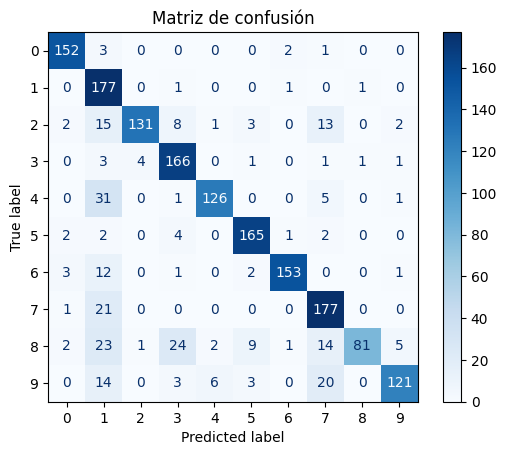

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(num_classes)
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.show()